# PCG ML/DL Training & Inference Pipeline

## Datasets

| Dataset | Task | Recordings | Labels | Download |
|---------|------|-----------|--------|----------|
| **PhysioNet 2016** | Normal vs Abnormal | 3,126 (databases A–E) | normal / abnormal | [physionet.org](https://physionet.org/content/challenge-2016/1.0.0/) |
| **CirCor DigiScope 2022** | Murmur Detection | 5,272 from 1,568 patients | present / absent / unknown + timing, shape, pitch, grade | [physionet.org](https://physionet.org/content/circor-heart-sound/1.0.0/) |
| **Kaggle mirror (2016)** | Same as above | Same | Same | [kaggle.com](https://www.kaggle.com/datasets/bjoernjostein/physionet-challenge-2016) |

## Models Trained

| # | Model | Type | Task |
|---|-------|------|------|
| 1 | Random Forest | ML (sklearn) | Normal vs Abnormal |
| 2 | XGBoost | ML (xgboost) | Normal vs Abnormal |
| 3 | 1D-CNN | DL (PyTorch) | Normal vs Abnormal |
| 4 | Mel-Spectrogram CNN | DL (PyTorch) | Normal vs Abnormal |
| 5 | Random Forest | ML (sklearn) | Murmur Detection |
| 6 | 1D-CNN | DL (PyTorch) | Murmur Detection |

All models end with an **inference cell** that loads your ESP32 recording and classifies it.

---
## 0. Download Datasets

Run **one** of the options below for each dataset. Adjust paths as needed.

In [ ]:
# ═══ OPTION A: wget (works on Linux / Colab / WSL) ═══

# PhysioNet 2016 — Normal vs Abnormal (169 MB zipped, ~1.1 GB unzipped)
# !wget -r -N -c -np -nH --cut-dirs=3 -P data/physionet2016 https://physionet.org/files/challenge-2016/1.0.0/

# CirCor 2022 — Murmur Detection (~2 GB)
# !wget -r -N -c -np -nH --cut-dirs=3 -P data/circor2022 https://physionet.org/files/circor-heart-sound/1.0.0/

# ═══ OPTION B: Kaggle CLI (PhysioNet 2016 only) ═══
# !pip install kaggle
# !kaggle datasets download bjoernjostein/physionet-challenge-2016 -p data/physionet2016 --unzip

# ═══ OPTION C: Google Cloud (PhysioNet 2016) ═══
# !gsutil -m cp -r gs://challenge-2016-1.0.0.physionet.org data/physionet2016

print("Uncomment the download method you prefer and run this cell.")
print("After downloading, set the paths below.")

## 1. Imports & Configuration

In [ ]:
!pip install pandas numpy matplotlib scipy scikit-learn xgboost torch torchaudio pywavelets --quiet

In [1]:
%matplotlib inline

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

# Audio / Signal
from scipy.io import wavfile
from scipy.signal import butter, filtfilt, iirnotch, resample
import librosa

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score, f1_score)
from xgboost import XGBClassifier

# DL
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print("✓ All imports OK")

Device: cpu
✓ All imports OK


In [2]:
# ════════════════════════════════════════════════
# PATHS — update these after downloading
# ════════════════════════════════════════════════

PHYSIONET_2016_DIR = "data/physionet2016"   # contains training-a/ through training-e/
CIRCOR_2022_DIR    = "data/circor2022"       # contains training_data/
YOUR_RECORDING     = "aman3.wav"             # your ESP32 WAV file

TARGET_SR = 2000    # PhysioNet 2016 is already at 2000 Hz
SEGMENT_SEC = 5     # seconds per training segment
N_MFCC = 20        # MFCC coefficients
N_MEL = 64         # Mel spectrogram bins
BATCH_SIZE = 32
EPOCHS = 30
LR = 1e-3
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

## 2. Shared Utilities

In [3]:
def load_and_preprocess(filepath, target_sr=2000):
    """Load WAV, convert to mono float64, resample if needed."""
    sr, data = wavfile.read(filepath)
    if len(data.shape) > 1:
        data = data[:, 0]
    data = data.astype(np.float64)
    
    # Resample if different SR
    if sr != target_sr:
        n_samples = int(len(data) * target_sr / sr)
        data = resample(data, n_samples)
        sr = target_sr
    
    return data, sr


def bandpass(data, lowcut, highcut, sr, order=4):
    nyq = 0.5 * sr
    highcut = min(highcut, nyq - 1)
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, data)


def segment_signal(data, sr, segment_sec=5):
    """Split signal into fixed-length segments. Discard remainder."""
    seg_len = int(sr * segment_sec)
    n_segs = len(data) // seg_len
    segments = []
    for i in range(n_segs):
        seg = data[i * seg_len : (i + 1) * seg_len]
        segments.append(seg)
    return segments


def extract_features(segment, sr, n_mfcc=20):
    """
    Extract features from one audio segment for ML models.
    Returns a flat feature vector.
    """
    # Normalize
    segment = segment / (np.max(np.abs(segment)) + 1e-10)
    
    # MFCCs
    mfccs = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=n_mfcc)
    mfcc_mean = np.mean(mfccs, axis=1)
    mfcc_std  = np.std(mfccs, axis=1)
    mfcc_delta = np.mean(librosa.feature.delta(mfccs), axis=1)
    
    # Spectral features
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=segment, sr=sr))
    spec_bw   = np.mean(librosa.feature.spectral_bandwidth(y=segment, sr=sr))
    spec_flat = np.mean(librosa.feature.spectral_flatness(y=segment))
    rolloff   = np.mean(librosa.feature.spectral_rolloff(y=segment, sr=sr))
    
    # Time-domain
    zcr    = np.mean(librosa.feature.zero_crossing_rate(y=segment))
    rms    = np.mean(librosa.feature.rms(y=segment))
    energy = np.sum(segment**2) / len(segment)
    
    # Shannon entropy
    eps = 1e-10
    norm = np.abs(segment) / (np.sum(np.abs(segment)) + eps)
    entropy = -np.sum(norm * np.log2(norm + eps))
    
    features = np.concatenate([
        mfcc_mean,          # 20
        mfcc_std,           # 20
        mfcc_delta,         # 20
        [spec_cent, spec_bw, spec_flat, rolloff],  # 4
        [zcr, rms, energy, entropy],                # 4
    ])
    return features  # total: 68 features


def make_mel_spectrogram(segment, sr, n_mels=64, fixed_width=128):
    """Generate a fixed-size mel spectrogram for CNN input."""
    segment = segment / (np.max(np.abs(segment)) + 1e-10)
    mel = librosa.feature.melspectrogram(y=segment, sr=sr, n_mels=n_mels, 
                                         fmax=sr//2)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    # Resize to fixed width
    if mel_db.shape[1] < fixed_width:
        mel_db = np.pad(mel_db, ((0,0), (0, fixed_width - mel_db.shape[1])))
    else:
        mel_db = mel_db[:, :fixed_width]
    
    return mel_db  # shape: (n_mels, fixed_width)

print("✓ Utilities defined")

✓ Utilities defined


---
# Part A: Normal vs. Abnormal Classification (PhysioNet 2016)

**3,126 recordings** across 5 databases (A–E), all at 2000 Hz.  
Labels: `1` = normal, `-1` = abnormal, stored in `REFERENCE.csv` per database.

### A1. Load PhysioNet 2016 Data

In [5]:
def load_physionet2016(base_dir, target_sr=2000, segment_sec=5):
    """
    Load all databases (training-a through training-e).
    Each has a REFERENCE.csv with columns: filename, label (1=normal, -1=abnormal)
    """
    all_features = []
    all_labels = []
    all_segments_raw = []
    all_mels = []
    
    databases = sorted(glob.glob(os.path.join(base_dir, 'training-*')))
    if not databases:
        # Try alternate structure
        databases = sorted(glob.glob(os.path.join(base_dir, '*', 'training-*')))
    
    print(f"Found {len(databases)} databases")
    
    for db_path in databases:
        db_name = os.path.basename(db_path)
        ref_file = os.path.join(db_path, 'REFERENCE.csv')
        
        if not os.path.exists(ref_file):
            print(f"  ⚠ No REFERENCE.csv in {db_name}, skipping")
            continue
        
        ref = pd.read_csv(ref_file, header=None, names=['filename', 'label'])
        print(f"  {db_name}: {len(ref)} recordings "
              f"(normal: {(ref.label==1).sum()}, abnormal: {(ref.label==-1).sum()})")
        
        for _, row in tqdm(ref.iterrows(), total=len(ref), desc=db_name, leave=False):
            wav_path = os.path.join(db_path, row['filename'] + '.wav')
            if not os.path.exists(wav_path):
                continue
            
            try:
                data, sr = load_and_preprocess(wav_path, target_sr)
                data = bandpass(data, 25, 400, sr)
                
                # Segment into fixed-length chunks
                segs = segment_signal(data, sr, segment_sec)
                label = 1 if row['label'] == 1 else 0  # 1=normal, 0=abnormal
                
                for seg in segs:
                    # ML features
                    feat = extract_features(seg, sr, N_MFCC)
                    all_features.append(feat)
                    all_labels.append(label)
                    
                    # Raw segment (for 1D-CNN)
                    all_segments_raw.append(seg)
                    
                    # Mel spectrogram (for 2D-CNN)
                    mel = make_mel_spectrogram(seg, sr, N_MEL)
                    all_mels.append(mel)
                    
            except Exception as e:
                continue
    
    X_feat = np.array(all_features)
    X_raw  = np.array(all_segments_raw)
    X_mel  = np.array(all_mels)
    y      = np.array(all_labels)
    
    print(f"\nTotal segments: {len(y)}")
    print(f"  Normal:   {(y==1).sum()} ({100*(y==1).mean():.1f}%)")
    print(f"  Abnormal: {(y==0).sum()} ({100*(y==0).mean():.1f}%)")
    print(f"Feature shape: {X_feat.shape}")
    print(f"Raw shape: {X_raw.shape}")
    print(f"Mel shape: {X_mel.shape}")
    
    return X_feat, X_raw, X_mel, y

# Uncomment when data is downloaded:
X_feat, X_raw, X_mel, y = load_physionet2016(PHYSIONET_2016_DIR, TARGET_SR, SEGMENT_SEC)


Found 6 databases
  training-a: 409 recordings (normal: 292, abnormal: 117)


training-a:   0%|          | 0/409 [00:00<?, ?it/s]

  training-b: 490 recordings (normal: 104, abnormal: 386)


training-b:   0%|          | 0/490 [00:00<?, ?it/s]

  training-c: 31 recordings (normal: 24, abnormal: 7)


...

  training-e: 2141 recordings (normal: 183, abnormal: 1958)


training-e:   0%|          | 0/2141 [00:00<?, ?it/s]

  training-f: 114 recordings (normal: 34, abnormal: 80)


training-f:   0%|          | 0/114 [00:00<?, ?it/s]


Total segments: 13015
  Normal:   3158 (24.3%)
  Abnormal: 9857 (75.7%)
Feature shape: (13015, 68)
Raw shape: (13015, 10000)
Mel shape: (13015, 64, 128)


### A2. ML Models: Random Forest + XGBoost

Training Random Forest...

Random Forest Results:
  Accuracy: 0.899
  F1 Score: 0.867
  AUC-ROC:  0.959
              precision    recall  f1-score   support

    Abnormal       0.95      0.92      0.93      1971
      Normal       0.76      0.85      0.80       632

    accuracy                           0.90      2603
   macro avg       0.86      0.88      0.87      2603
weighted avg       0.90      0.90      0.90      2603

Training XGBoost...

XGBoost Results:
  Accuracy: 0.916
  F1 Score: 0.889
  AUC-ROC:  0.972
              precision    recall  f1-score   support

    Abnormal       0.96      0.93      0.94      1971
      Normal       0.80      0.87      0.83       632

    accuracy                           0.92      2603
   macro avg       0.88      0.90      0.89      2603
weighted avg       0.92      0.92      0.92      2603



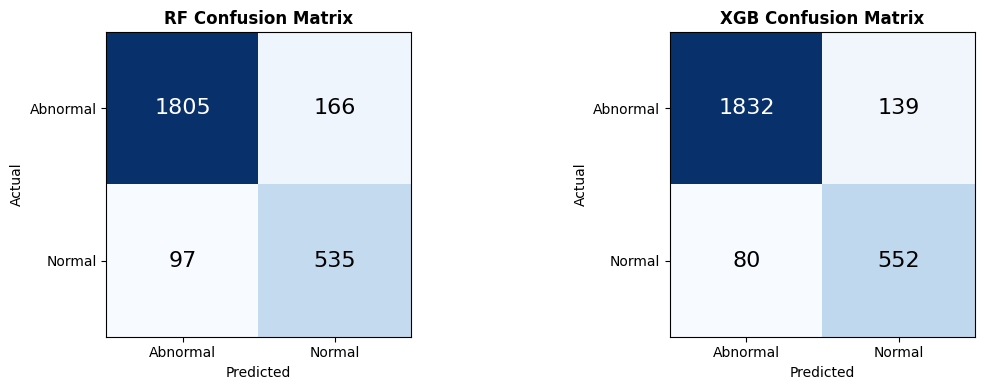

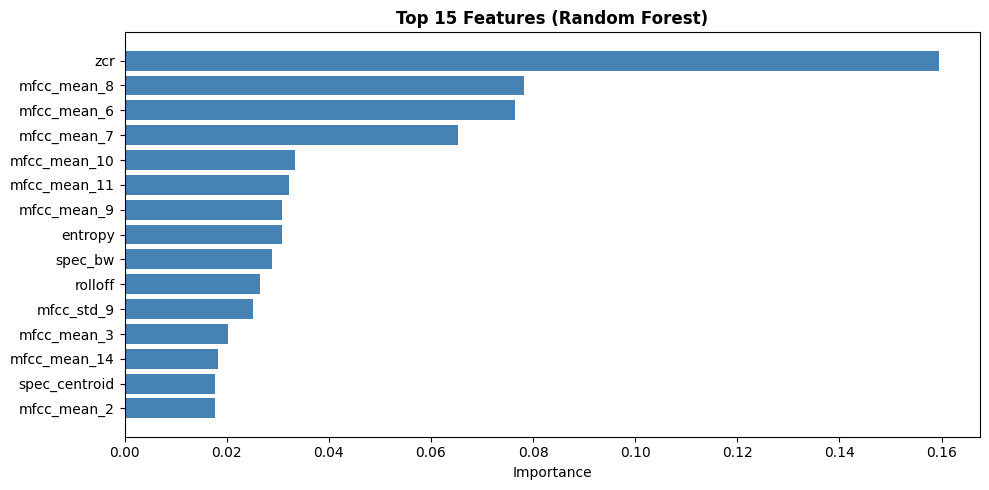

In [7]:
def train_ml_models(X_feat, y):
    """Train Random Forest and XGBoost on extracted features."""
    
    # Handle NaN/Inf
    X_feat = np.nan_to_num(X_feat, nan=0, posinf=0, neginf=0)
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_feat, y, test_size=0.2, stratify=y, random_state=SEED
    )
    
    # Scale
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)
    
    results = {}
    
    # ── Random Forest ──
    print("Training Random Forest...")
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=5,
        class_weight='balanced',  # handles imbalanced data
        random_state=SEED,
        n_jobs=-1
    )
    rf.fit(X_train_s, y_train)
    rf_pred = rf.predict(X_test_s)
    rf_prob = rf.predict_proba(X_test_s)[:, 1]
    
    print(f"\nRandom Forest Results:")
    print(f"  Accuracy: {accuracy_score(y_test, rf_pred):.3f}")
    print(f"  F1 Score: {f1_score(y_test, rf_pred, average='macro'):.3f}")
    print(f"  AUC-ROC:  {roc_auc_score(y_test, rf_prob):.3f}")
    print(classification_report(y_test, rf_pred, target_names=['Abnormal', 'Normal']))
    
    results['rf'] = {'model': rf, 'scaler': scaler, 'pred': rf_pred, 'prob': rf_prob}
    
    # ── XGBoost ──
    
    print("Training XGBoost...")
    
    # Calculate scale_pos_weight for imbalance
    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()
    
    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        scale_pos_weight=n_neg / n_pos,
        eval_metric='logloss',
        random_state=SEED,
        use_label_encoder=False
    )
    xgb.fit(X_train_s, y_train, 
            eval_set=[(X_test_s, y_test)], verbose=False)
    xgb_pred = xgb.predict(X_test_s)
    xgb_prob = xgb.predict_proba(X_test_s)[:, 1]
    
    print(f"\nXGBoost Results:")
    print(f"  Accuracy: {accuracy_score(y_test, xgb_pred):.3f}")
    print(f"  F1 Score: {f1_score(y_test, xgb_pred, average='macro'):.3f}")
    print(f"  AUC-ROC:  {roc_auc_score(y_test, xgb_prob):.3f}")
    print(classification_report(y_test, xgb_pred, target_names=['Abnormal', 'Normal']))
    
    results['xgb'] = {'model': xgb, 'scaler': scaler, 'pred': xgb_pred, 'prob': xgb_prob}
    
    
    # ── Confusion matrices ──
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, (name, res) in zip(axes, results.items()):
        cm = confusion_matrix(y_test, res['pred'])
        ax.imshow(cm, cmap='Blues')
        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=16,
                       color='white' if cm[i, j] > cm.max()/2 else 'black')
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(['Abnormal', 'Normal'])
        ax.set_yticklabels(['Abnormal', 'Normal'])
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
        ax.set_title(f'{name.upper()} Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Feature importance
    importances = rf.feature_importances_
    feat_names = ([f'mfcc_mean_{i}' for i in range(N_MFCC)] +
                  [f'mfcc_std_{i}' for i in range(N_MFCC)] +
                  [f'mfcc_delta_{i}' for i in range(N_MFCC)] +
                  ['spec_centroid', 'spec_bw', 'spec_flat', 'rolloff'] +
                  ['zcr', 'rms', 'energy', 'entropy'])
    top_idx = np.argsort(importances)[-15:]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh([feat_names[i] for i in top_idx], importances[top_idx], color='steelblue')
    ax.set_title('Top 15 Features (Random Forest)', fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
    
    return results, scaler, X_test_s, y_test

# Uncomment when data is loaded:
ml_results, scaler, X_test_s, y_test = train_ml_models(X_feat, y)
#print("Run train_ml_models(X_feat, y) after loading data.")

### A3. DL Model 1: 1D-CNN on Raw Waveform

In [8]:
class PCGDataset(Dataset):
    """PyTorch dataset for PCG segments."""
    def __init__(self, X, y, mode='raw'):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
        self.mode = mode
        
        if mode == 'raw':
            # Add channel dimension: (N, L) → (N, 1, L)
            self.X = self.X.unsqueeze(1)
        elif mode == 'mel':
            # Add channel dimension: (N, H, W) → (N, 1, H, W)
            self.X = self.X.unsqueeze(1)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class CNN1D(nn.Module):
    """1D CNN for raw waveform classification."""
    def __init__(self, input_length, n_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv1d(1, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),
            
            # Block 2
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),
            
            # Block 3
            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.3),
            
            # Block 4
            nn.Conv1d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),  # global average pooling
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, n_classes),
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


print("✓ 1D-CNN defined")

✓ 1D-CNN defined


### A4. DL Model 2: 2D-CNN on Mel Spectrogram

In [9]:
class CNN2D_Mel(nn.Module):
    """2D CNN on mel spectrograms — similar to image classification."""
    def __init__(self, n_mels=64, width=128, n_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: (1, 64, 128) → (16, 32, 64)
            nn.Conv2d(1, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 2: → (32, 16, 32)
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),
            
            # Block 3: → (64, 8, 16)
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),
            
            # Block 4: → (128, 4, 8)
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, n_classes),
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("✓ 2D Mel-CNN defined")

✓ 2D Mel-CNN defined


### A5. Training Loop

In [ ]:
def train_dl_model(model, train_loader, val_loader, epochs=30, lr=1e-3, 
                    class_weights=None, model_name="model"):
    """Generic training loop with early stopping."""
    model = model.to(DEVICE)
    
    if class_weights is not None:
        criterion = nn.CrossEntropyLoss(weight=torch.FloatTensor(class_weights).to(DEVICE))
    else:
        criterion = nn.CrossEntropyLoss()
    
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    
    best_val_f1 = 0
    best_state = None
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_acc': []}
    
    for epoch in range(epochs):
        # ── Train ──
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        
        # ── Validate ──
        model.eval()
        val_loss = 0
        all_preds, all_true = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                preds = outputs.argmax(dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_true.extend(y_batch.cpu().numpy())
        val_loss /= len(val_loader)
        
        val_f1  = f1_score(all_true, all_preds, average='macro')
        val_acc = accuracy_score(all_true, all_preds)
        scheduler.step(val_loss)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)
        history['val_acc'].append(val_acc)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
                  f"Val F1: {val_f1:.3f} | Val Acc: {val_acc:.3f}")
        
        # Early stopping
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 10:
                print(f"  Early stopping at epoch {epoch+1}")
                break
    
    # Load best model
    model.load_state_dict(best_state)
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'], label='Val')
    axes[0].set_title(f'{model_name} — Loss', fontweight='bold')
    axes[0].legend(); axes[0].set_xlabel('Epoch')
    
    axes[1].plot(history['val_f1'], label='F1', color='green')
    axes[1].plot(history['val_acc'], label='Accuracy', color='blue')
    axes[1].set_title(f'{model_name} — Metrics', fontweight='bold')
    axes[1].legend(); axes[1].set_xlabel('Epoch')
    plt.tight_layout()
    plt.show()
    
    # Final report
    print(f"\nBest Val F1: {best_val_f1:.3f}")
    n_unique = len(set(all_true))
    if n_unique == 2:
        names = ['Abnormal', 'Normal']
    elif n_unique == 3:
        names = ['Absent', 'Unknown', 'Present']
    else:
        names = [str(i) for i in range(n_unique)]
    print(classification_report(all_true, all_preds, target_names=names))
    
    return model, history

print("✓ Training function defined")

In [ ]:
def run_dl_training(X_raw, X_mel, y):
    """Train both 1D-CNN and Mel-CNN."""
    
    # Normalize raw signals
    X_raw_norm = X_raw / (np.max(np.abs(X_raw), axis=1, keepdims=True) + 1e-10)
    
    # Split
    idx = np.arange(len(y))
    idx_train, idx_test = train_test_split(idx, test_size=0.2, stratify=y, random_state=SEED)
    
    # Class weights for imbalanced data
    n_abnormal = (y[idx_train] == 0).sum()
    n_normal   = (y[idx_train] == 1).sum()
    total = n_abnormal + n_normal
    class_weights = [total / (2 * n_abnormal), total / (2 * n_normal)]
    print(f"Class weights: abnormal={class_weights[0]:.2f}, normal={class_weights[1]:.2f}")
    
    models = {}
    
    # ── 1D-CNN ──
    print("\n" + "="*50)
    print("Training 1D-CNN on raw waveform")
    print("="*50)
    
    train_ds = PCGDataset(X_raw_norm[idx_train], y[idx_train], mode='raw')
    val_ds   = PCGDataset(X_raw_norm[idx_test],  y[idx_test],  mode='raw')
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
    
    input_len = X_raw_norm.shape[1]
    cnn1d = CNN1D(input_len, n_classes=2)
    print(f"Parameters: {sum(p.numel() for p in cnn1d.parameters()):,}")
    
    cnn1d, hist1d = train_dl_model(cnn1d, train_dl, val_dl, EPOCHS, LR, 
                                    class_weights, "1D-CNN")
    models['cnn1d'] = cnn1d
    
    # ── Mel-CNN ──
    print("\n" + "="*50)
    print("Training 2D Mel-CNN on spectrograms")
    print("="*50)
    
    train_ds_mel = PCGDataset(X_mel[idx_train], y[idx_train], mode='mel')
    val_ds_mel   = PCGDataset(X_mel[idx_test],  y[idx_test],  mode='mel')
    train_dl_mel = DataLoader(train_ds_mel, batch_size=BATCH_SIZE, shuffle=True)
    val_dl_mel   = DataLoader(val_ds_mel,   batch_size=BATCH_SIZE)
    
    cnn2d = CNN2D_Mel(N_MEL, 128, n_classes=2)
    print(f"Parameters: {sum(p.numel() for p in cnn2d.parameters()):,}")
    
    cnn2d, hist2d = train_dl_model(cnn2d, train_dl_mel, val_dl_mel, EPOCHS, LR,
                                    class_weights, "Mel-CNN")
    models['cnn2d'] = cnn2d
    
    return models, idx_test

# Uncomment when data is loaded:
# dl_models, test_idx = run_dl_training(X_raw, X_mel, y)
print("Run run_dl_training(X_raw, X_mel, y) after loading data.")

### A6. Save Trained Models

In [ ]:
def save_models(ml_results, dl_models, scaler, save_dir='saved_models'):
    """Save all trained models to disk."""
    os.makedirs(save_dir, exist_ok=True)
    
    # ML models
    import joblib
    if 'rf' in ml_results:
        joblib.dump(ml_results['rf']['model'], f'{save_dir}/rf_normal_abnormal.pkl')
    if 'xgb' in ml_results:
        joblib.dump(ml_results['xgb']['model'], f'{save_dir}/xgb_normal_abnormal.pkl')
    joblib.dump(scaler, f'{save_dir}/scaler_normal_abnormal.pkl')
    
    # DL models
    if 'cnn1d' in dl_models:
        torch.save(dl_models['cnn1d'].state_dict(), f'{save_dir}/cnn1d_normal_abnormal.pth')
    if 'cnn2d' in dl_models:
        torch.save(dl_models['cnn2d'].state_dict(), f'{save_dir}/cnn2d_normal_abnormal.pth')
    
    print(f"✓ All models saved to {save_dir}/")

# Uncomment after training:
# save_models(ml_results, dl_models, scaler)
print("Run save_models() after training.")

---
# Part B: Murmur Detection (CirCor DigiScope 2022)

**5,272 recordings** from 1,568 pediatric patients.  
Labels per patient: `Present`, `Absent`, `Unknown` (murmur).  
Includes segmentation annotations (S1, systole, S2, diastole boundaries).

In [ ]:
def load_circor2022(base_dir, target_sr=2000, segment_sec=5):
    training_dir = os.path.join(base_dir, 'training')
    csv_path = os.path.join(base_dir, 'training_data.csv')
    
    # ── Load labels from CSV ──
    df = pd.read_csv(csv_path)
    print(f"CSV loaded: {len(df)} patients")
    print(f"Murmur distribution:")
    print(f"  1 (Present):  {(df['Murmurs']==1).sum()}")
    print(f"  2 (Absent):   {(df['Murmurs']==2).sum()}")
    print(f"  3 (Unknown):  {(df['Murmurs']==3).sum()}")
    
    # Build patient_id → label mapping
    # CSV codes: 1=Present, 2=Absent, 3=Unknown
    # Our codes: 0=Absent, 1=Unknown, 2=Present
    code_map = {1: 2, 2: 0, 3: 1}  # CSV code → our label
    label_map = {}
    for _, row in df.iterrows():
        pid = str(int(row['Patient_ID']))
        label_map[pid] = code_map[row['Murmurs']]
    
    # ── Find all WAV files ──
    wav_files = sorted(glob.glob(os.path.join(training_dir, '*.wav')))
    print(f"\nWAV files found: {len(wav_files)}")
    
    all_features = []
    all_labels = []
    all_raw = []
    all_mels = []
    label_counts = {'Absent': 0, 'Unknown': 0, 'Present': 0}
    label_names = {0: 'Absent', 1: 'Unknown', 2: 'Present'}
    skipped = 0
    
    for wav_path in tqdm(wav_files, desc="Processing recordings"):
        basename = os.path.splitext(os.path.basename(wav_path))[0]  # "85343_MV"
        patient_id = basename.rsplit('_', 1)[0]                      # "85343"
        
        label = label_map.get(patient_id, None)
        if label is None:
            skipped += 1
            continue
        
        label_counts[label_names[label]] += 1
        
        try:
            data, sr = load_and_preprocess(wav_path, target_sr)
            data = bandpass(data, 25, 400, sr)
            
            for seg in segment_signal(data, sr, segment_sec):
                all_features.append(extract_features(seg, sr, N_MFCC))
                all_labels.append(label)
                all_raw.append(seg)
                all_mels.append(make_mel_spectrogram(seg, sr, N_MEL))
        except:
            continue
    
    if skipped > 0:
        print(f"⚠ Skipped {skipped} WAVs (patient ID not in CSV)")
    
    X_feat = np.array(all_features)
    X_raw  = np.array(all_raw)
    X_mel  = np.array(all_mels)
    y      = np.array(all_labels)
    
    print(f"\nPer-WAV distribution: {label_counts}")
    print(f"Total segments: {len(y)}")
    for lbl, name in [(0, 'Absent'), (1, 'Unknown'), (2, 'Present')]:
        count = (y == lbl).sum()
        if count > 0:
            print(f"  {name}: {count} ({100 * count / len(y):.1f}%)")
    
    return X_feat, X_raw, X_mel, y


# Uncomment when data is downloaded:
X_feat_m, X_raw_m, X_mel_m, y_m = load_circor2022(CIRCOR_2022_DIR, TARGET_SR, SEGMENT_SEC)


### B2. Train Murmur Models

In [ ]:
def train_murmur_models(X_feat, X_raw, X_mel, y):
    """
    Train murmur detection models.
    Can be run as 3-class (Absent/Unknown/Present) or binary (Absent vs Present).
    """
    # Option: binary classification — drop Unknown
    # mask = y != 1
    # X_feat, X_raw, X_mel, y = X_feat[mask], X_raw[mask], X_mel[mask], y[mask]
    # y = (y == 2).astype(int)  # 1=Present, 0=Absent
    
    n_classes = len(np.unique(y))
    class_names = {0: 'Absent', 1: 'Unknown', 2: 'Present'} if n_classes == 3 else {0: 'Absent', 1: 'Present'}
    target_names = [class_names[i] for i in range(n_classes)]
    
    print(f"Classes: {n_classes} — {target_names}")
    
    X_feat = np.nan_to_num(X_feat)
    
    # Split
    X_tr, X_te, y_tr, y_te = train_test_split(X_feat, y, test_size=0.2, 
                                                stratify=y, random_state=SEED)
    idx_all = np.arange(len(y))
    idx_tr, idx_te = train_test_split(idx_all, test_size=0.2, stratify=y, random_state=SEED)
    
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)
    
    # ── Random Forest ──
    print("\nTraining Random Forest...")
    rf = RandomForestClassifier(n_estimators=300, max_depth=20, 
                                 class_weight='balanced', random_state=SEED, n_jobs=-1)
    rf.fit(X_tr_s, y_tr)
    rf_pred = rf.predict(X_te_s)
    print(f"RF Accuracy: {accuracy_score(y_te, rf_pred):.3f}")
    print(f"RF F1 Macro: {f1_score(y_te, rf_pred, average='macro'):.3f}")
    print(classification_report(y_te, rf_pred, target_names=target_names))
    
    # ── 1D-CNN ──
    print("\nTraining 1D-CNN for murmur detection...")
    X_raw_norm = X_raw / (np.max(np.abs(X_raw), axis=1, keepdims=True) + 1e-10)
    
    train_ds = PCGDataset(X_raw_norm[idx_tr], y[idx_tr], mode='raw')
    val_ds   = PCGDataset(X_raw_norm[idx_te], y[idx_te], mode='raw')
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_dl   = DataLoader(val_ds, batch_size=BATCH_SIZE)
    
    # Class weights
    from collections import Counter
    counts = Counter(y[idx_tr].tolist())
    total = sum(counts.values())
    cw = [total / (n_classes * counts[i]) for i in range(n_classes)]
    
    cnn = CNN1D(X_raw_norm.shape[1], n_classes=n_classes)
    cnn, _ = train_dl_model(cnn, train_dl, val_dl, EPOCHS, LR, cw, "Murmur 1D-CNN")
    
    # Save
    os.makedirs('saved_models', exist_ok=True)
    import joblib
    joblib.dump(rf, 'saved_models/rf_murmur.pkl')
    joblib.dump(scaler, 'saved_models/scaler_murmur.pkl')
    torch.save(cnn.state_dict(), 'saved_models/cnn1d_murmur.pth')
    print("\n✓ Murmur models saved")
    
    return rf, cnn, scaler

# Uncomment when data is loaded:
# rf_m, cnn_m, scaler_m = train_murmur_models(X_feat_m, X_raw_m, X_mel_m, y_m)
print("Run train_murmur_models() after loading CirCor data.")

---
# Part C: Inference on Your ESP32 Recording

Apply all trained models to your own WAV file.  
Handles resampling from 500 Hz → 2000 Hz automatically.

In [ ]:
def inference_on_recording(filepath, ml_results=None, dl_models=None, 
                            scaler=None, target_sr=2000, segment_sec=5):
    """
    Full inference pipeline on your ESP32 recording.
    Resamples from your hardware SR to the training SR.
    """
    print(f"Loading: {filepath}")
    data, sr = load_and_preprocess(filepath, target_sr)
    data = bandpass(data, 25, 400, sr)
    
    segments = segment_signal(data, sr, segment_sec)
    print(f"Sample rate after resampling: {sr} Hz")
    print(f"Segments ({segment_sec}s each): {len(segments)}")
    
    if len(segments) == 0:
        print("⚠ Recording too short for analysis")
        return
    
    # Extract features for each segment
    features = np.array([extract_features(seg, sr, N_MFCC) for seg in segments])
    features = np.nan_to_num(features)
    
    # Normalize raw segments for CNN
    raw_segs = np.array(segments)
    raw_norm = raw_segs / (np.max(np.abs(raw_segs), axis=1, keepdims=True) + 1e-10)
    
    # Mel spectrograms
    mels = np.array([make_mel_spectrogram(seg, sr, N_MEL) for seg in segments])
    
    results_per_segment = []
    
    print(f"\n{'='*60}")
    print(f"  INFERENCE RESULTS")
    print(f"{'='*60}")
    
    # ── ML Models ──
    if ml_results and scaler:
        feats_scaled = scaler.transform(features)
        
        for name, res in ml_results.items():
            model = res['model']
            preds = model.predict(feats_scaled)
            probs = model.predict_proba(feats_scaled)
            
            n_normal = (preds == 1).sum()
            n_abnormal = (preds == 0).sum()
            avg_normal_prob = np.mean(probs[:, 1])
            
            print(f"\n  {name.upper()} (Normal vs Abnormal):")
            print(f"    Per-segment: {n_normal} normal, {n_abnormal} abnormal")
            print(f"    Avg P(normal): {avg_normal_prob:.3f}")
            
            # Majority vote
            overall = "NORMAL" if n_normal > n_abnormal else "ABNORMAL"
            confidence = max(n_normal, n_abnormal) / len(preds) * 100
            print(f"    → Overall: {overall} (confidence: {confidence:.0f}%)")
    
    # ── DL Models ──
    if dl_models:
        for name, model in dl_models.items():
            model.eval()
            model = model.to(DEVICE)
            
            with torch.no_grad():
                if '1d' in name:
                    X = torch.FloatTensor(raw_norm).unsqueeze(1).to(DEVICE)
                elif '2d' in name or 'mel' in name:
                    X = torch.FloatTensor(mels).unsqueeze(1).to(DEVICE)
                else:
                    continue
                
                outputs = model(X)
                probs = torch.softmax(outputs, dim=1).cpu().numpy()
                preds = outputs.argmax(dim=1).cpu().numpy()
            
            n_normal = (preds == 1).sum()
            n_abnormal = (preds == 0).sum()
            
            print(f"\n  {name.upper()} (Normal vs Abnormal):")
            print(f"    Per-segment: {n_normal} normal, {n_abnormal} abnormal")
            print(f"    Avg P(normal): {np.mean(probs[:, 1]):.3f}")
            
            overall = "NORMAL" if n_normal > n_abnormal else "ABNORMAL"
            confidence = max(n_normal, n_abnormal) / len(preds) * 100
            print(f"    → Overall: {overall} (confidence: {confidence:.0f}%)")
    
    # ── Per-segment visualization ──
    if ml_results and 'rf' in ml_results:
        feats_scaled = scaler.transform(features)
        probs = ml_results['rf']['model'].predict_proba(feats_scaled)[:, 1]
        
        time_axis = np.arange(len(data)) / sr
        fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
        
        axes[0].plot(time_axis, data, color='gray', lw=0.4)
        axes[0].set_title('Your Recording (resampled to 2000 Hz)', fontweight='bold')
        axes[0].set_ylabel('Amplitude')
        
        for i, prob in enumerate(probs):
            t_start = i * segment_sec
            t_end = t_start + segment_sec
            color = '#2ecc71' if prob > 0.5 else '#e74c3c'
            alpha = 0.3
            axes[0].axvspan(t_start, t_end, alpha=alpha, color=color)
            axes[1].bar(t_start + segment_sec/2, prob, width=segment_sec*0.9,
                       color='#2ecc71' if prob > 0.5 else '#e74c3c', alpha=0.7)
        
        axes[1].axhline(y=0.5, color='black', ls='--', lw=1)
        axes[1].set_ylabel('P(Normal)')
        axes[1].set_xlabel('Time (seconds)')
        axes[1].set_title('Per-Segment Classification Probability', fontweight='bold')
        axes[1].set_ylim(0, 1)
        
        plt.tight_layout()
        plt.show()

# ── Run inference ──
# inference_on_recording(YOUR_RECORDING, ml_results, dl_models, scaler)
print("Run inference_on_recording() after training models.")

### C2. Load Saved Models & Run Inference

In [ ]:
def load_and_infer(filepath, model_dir='saved_models', target_sr=2000, segment_sec=5):
    """Load saved models from disk and run inference."""
    import joblib
    
    # Load
    data, sr = load_and_preprocess(filepath, target_sr)
    data = bandpass(data, 25, 400, sr)
    segments = segment_signal(data, sr, segment_sec)
    
    if not segments:
        print("⚠ Recording too short")
        return
    
    features = np.nan_to_num(np.array([extract_features(s, sr, N_MFCC) for s in segments]))
    raw_norm = np.array(segments)
    raw_norm = raw_norm / (np.max(np.abs(raw_norm), axis=1, keepdims=True) + 1e-10)
    
    print(f"Segments: {len(segments)} × {segment_sec}s")
    
    # ── Normal vs Abnormal ──
    rf_path = f'{model_dir}/rf_normal_abnormal.pkl'
    sc_path = f'{model_dir}/scaler_normal_abnormal.pkl'
    
    if os.path.exists(rf_path):
        rf = joblib.load(rf_path)
        scaler = joblib.load(sc_path)
        feats_s = scaler.transform(features)
        preds = rf.predict(feats_s)
        probs = rf.predict_proba(feats_s)[:, 1]
        
        print(f"\n── Normal vs Abnormal (Random Forest) ──")
        print(f"  Normal segments:   {(preds==1).sum()}/{len(preds)}")
        print(f"  Abnormal segments: {(preds==0).sum()}/{len(preds)}")
        print(f"  Avg P(Normal): {np.mean(probs):.3f}")
        overall = "NORMAL" if (preds==1).sum() > (preds==0).sum() else "ABNORMAL"
        print(f"  → Overall: {overall}")
    
    cnn_path = f'{model_dir}/cnn1d_normal_abnormal.pth'
    if os.path.exists(cnn_path):
        input_len = raw_norm.shape[1]
        cnn = CNN1D(input_len, n_classes=2)
        cnn.load_state_dict(torch.load(cnn_path, map_location='cpu'))
        cnn.eval()
        with torch.no_grad():
            X = torch.FloatTensor(raw_norm).unsqueeze(1)
            out = cnn(X)
            p = torch.softmax(out, dim=1).numpy()
            pred = out.argmax(dim=1).numpy()
        print(f"\n── Normal vs Abnormal (1D-CNN) ──")
        print(f"  Normal: {(pred==1).sum()}/{len(pred)} | Abnormal: {(pred==0).sum()}/{len(pred)}")
        print(f"  → Overall: {'NORMAL' if (pred==1).sum() > (pred==0).sum() else 'ABNORMAL'}")
    
    # ── Murmur ──
    mr_path = f'{model_dir}/rf_murmur.pkl'
    ms_path = f'{model_dir}/scaler_murmur.pkl'
    
    if os.path.exists(mr_path):
        rf_m = joblib.load(mr_path)
        sc_m = joblib.load(ms_path)
        feats_m = sc_m.transform(features)
        preds_m = rf_m.predict(feats_m)
        
        murmur_names = {0: 'Absent', 1: 'Unknown', 2: 'Present'}
        print(f"\n── Murmur Detection (Random Forest) ──")
        for lbl, name in murmur_names.items():
            print(f"  {name}: {(preds_m==lbl).sum()}/{len(preds_m)}")
        majority = murmur_names[np.bincount(preds_m).argmax()]
        print(f"  → Overall: Murmur {majority}")

# Uncomment to run:
# load_and_infer(YOUR_RECORDING)
print("Run load_and_infer() after training and saving models.")

---
## ⚕️ Disclaimer

This pipeline is for **educational and research purposes only**. It is **NOT** a medical diagnostic tool.  
Always consult a qualified healthcare professional for cardiac assessment.

## References

1. Liu et al., "An open access database for the evaluation of heart sound algorithms", *Physiol. Meas.*, 2016  
2. Oliveira et al., "The CirCor DigiScope Phonocardiogram Dataset", *PhysioNet*, 2022  
3. Springer et al., "Logistic Regression-HSMM-Based Heart Sound Segmentation", *IEEE TBME*, 2016  
4. Renna et al., "Deep Convolutional Neural Networks for Heart Sound Segmentation", *IEEE JBHI*, 2019